<a href="https://colab.research.google.com/github/Minsoo1036/Applied-Data-Analysis-Study/blob/main/IRF_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install yfinance statsmodels

/tmp/ipykernel_6418/2124591479.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2015-01-01")["Close"]
[*********************100%***********************]  3 of 3 completed
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 23, Apr, 2026
Time:                     02:28:52
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -26.4989
Nobs:                     2718.00    HQIC:                  -26.6280
Log likelihood:           24809.7    FPE:                2.53437e-12
AIC:                     -26.7011    Det(Omega_mle):     2.44960e-12
--------------------------------------------------------------------
Results for equation RATE
              coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------
const            0.000254         0.000103            2.470           0.013
L1.RATE         -0.102191         0.019287           -5.298           0.000
L1.SPX          -0.216559         0.009592          -22.576           0.000
L1.KR

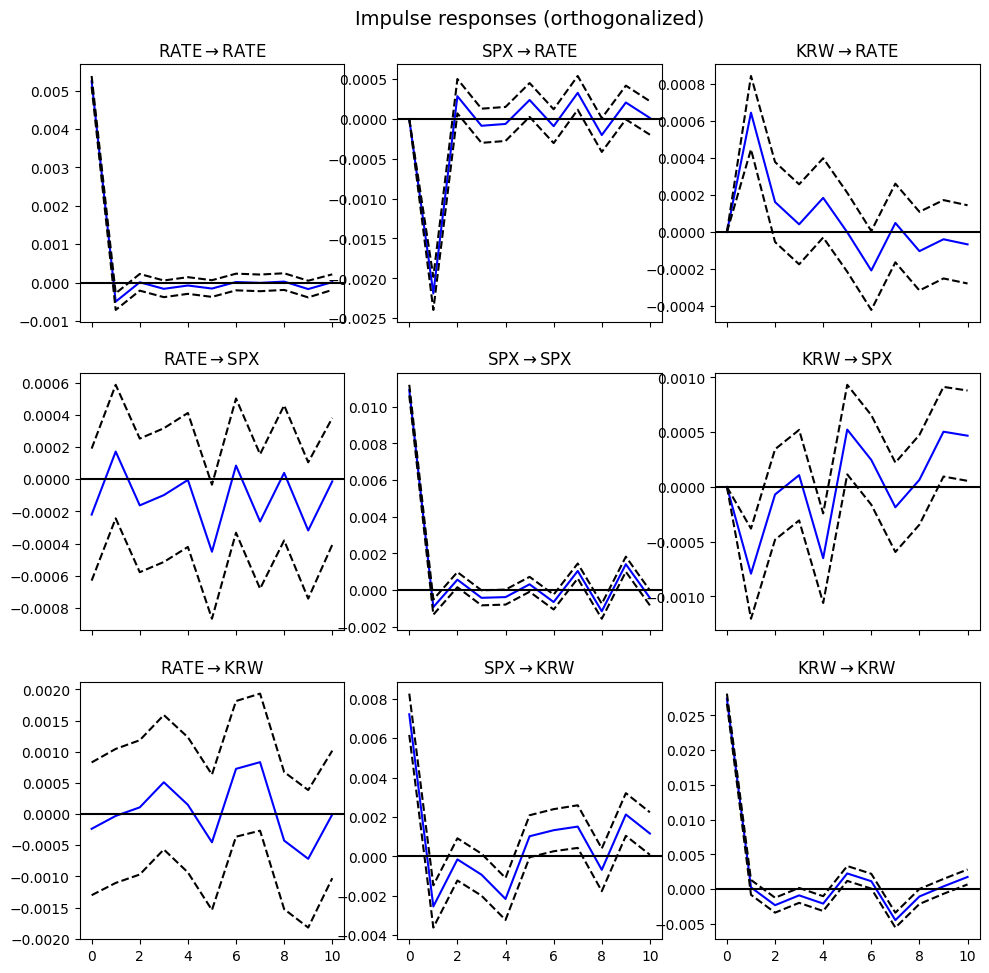

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
from statsmodels.tsa.api import VAR
import matplotlib.pyplot as plt

# =========================================
# 1. 데이터 다운로드
# =========================================
tickers = ["^TNX", "^GSPC", "KRW=X"]

data = yf.download(tickers, start="2015-01-01")["Close"]

data.columns = ["RATE", "SPX", "KRW"]

# 로그수익률 (stationary)
df = np.log(data).diff().dropna()

# =========================================
# 2. VAR 모델 적합
# =========================================
model = VAR(df)

lag_order = model.select_order(maxlags=10)
p = lag_order.aic  # AIC 기준

var_model = model.fit(p)

print(var_model.summary())

# =========================================
# 3. IRF 계산
# =========================================
irf = var_model.irf(10)  # 10 step

# =========================================
# 4. IRF plot
# =========================================
irf.plot(orth=True)
plt.show()

In [3]:
df = df[["RATE", "SPX", "KRW"]]

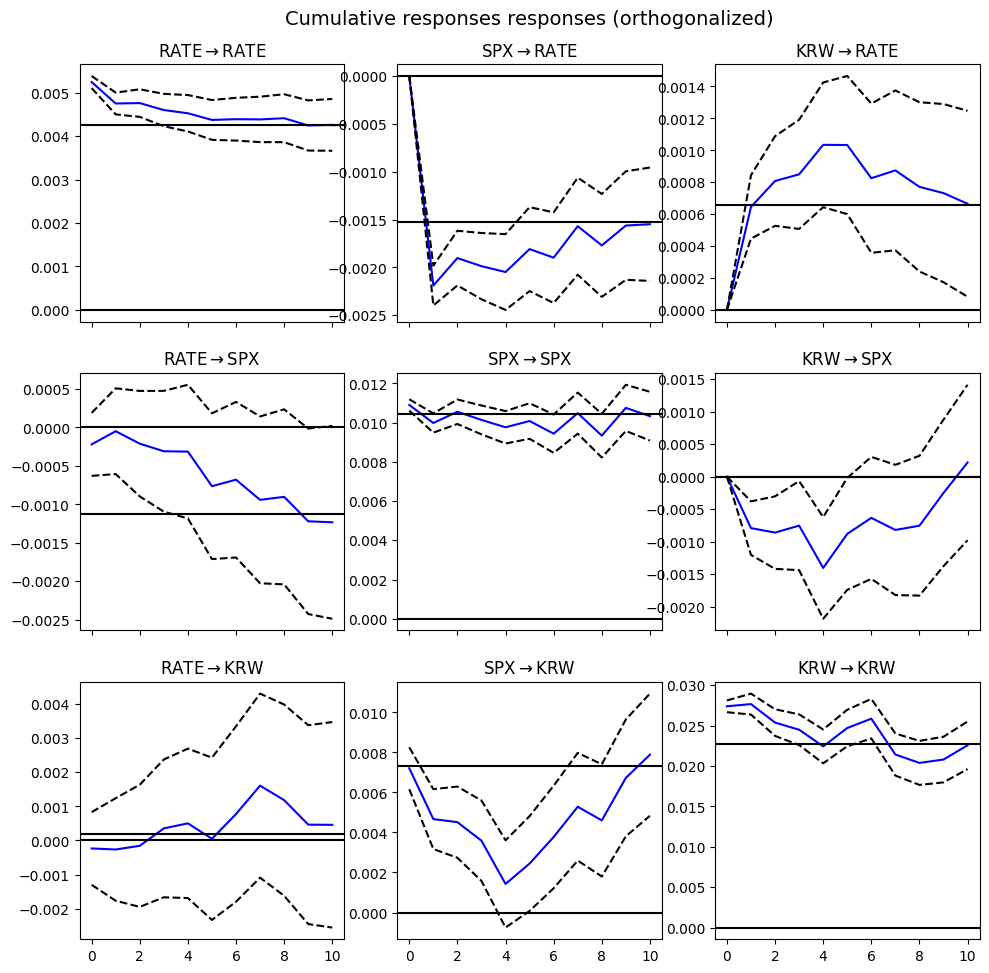

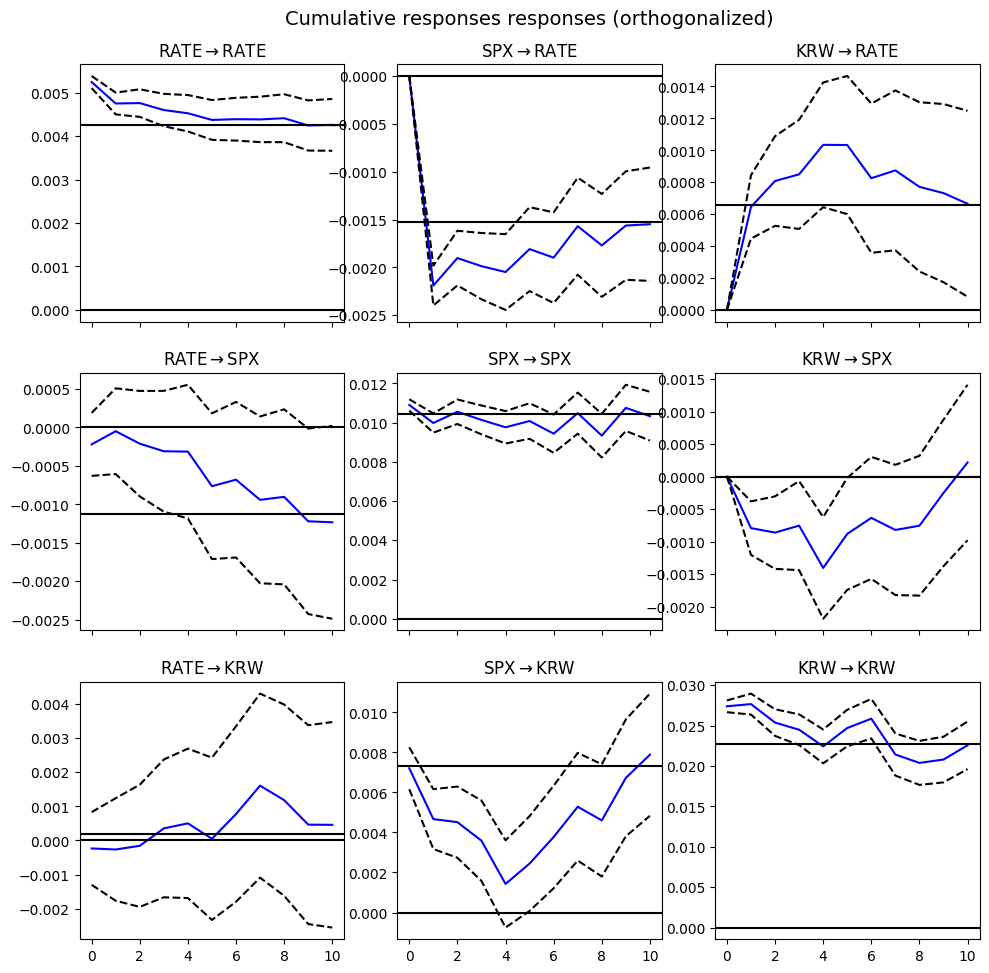

In [4]:
irf.plot_cum_effects(orth=True)

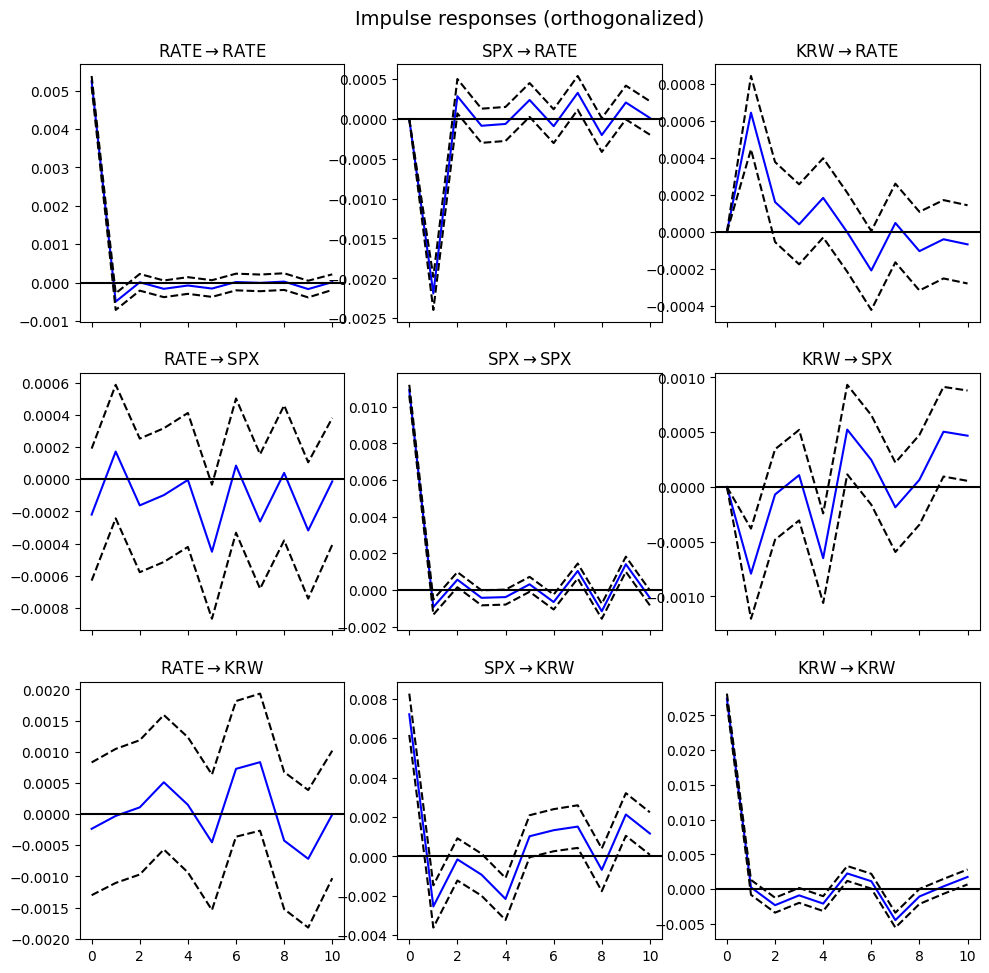

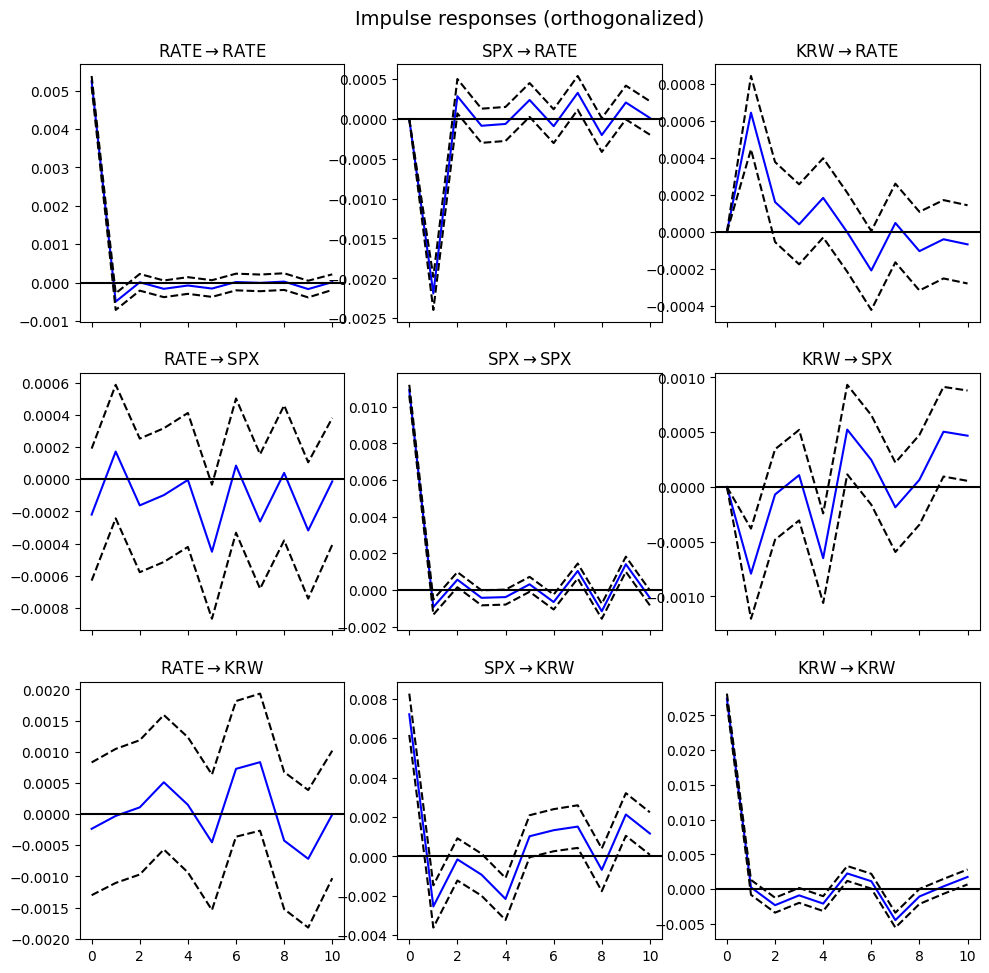

In [5]:
irf.plot(orth=True, signif=0.05)

In [6]:
data

,RATE,SPX,KRW
Date,,,
2015-01-01,1092.699951,NaN,NaN
2015-01-02,1093.599976,2058.199951,2.123
2015-01-05,1111.000000,2020.579956,2.039
2015-01-06,1108.500000,2002.609985,1.963
2015-01-07,1097.300049,2025.900024,1.954
...,...,...,...
2026-04-17,1477.920044,7126.060059,4.246
2026-04-20,1465.150024,7109.140137,4.250
2026-04-21,1469.260010,7064.009766,4.292


In [7]:
# IRF (returns 기준)
irf = var_model.irf(20)

# cumulative IRF
irf_cum = irf.cum_effects

In [8]:
# index 순서 확인
print(df.columns)

# 예: RATE shock → SPX 반응
response = irf_cum[:, df.columns.get_loc("SPX"), df.columns.get_loc("RATE")]

Index(['RATE', 'SPX', 'KRW'], dtype='object')


In [9]:
def get_level_irf(irf, df_cols, shock, response):
    irf_cum = irf.cum_effects

    i = df_cols.get_loc(response)
    j = df_cols.get_loc(shock)

    log_irf = irf_cum[:, i, j]
    level_irf = np.exp(log_irf)

    return level_irf

In [10]:
level_irf = get_level_irf(irf, df.columns, "RATE", "SPX")

In [11]:
horizon = len(level_irf)

price_path = np.insert(level_irf, 0, 1.0)  # 시작점 = 1

steps = np.arange(0, horizon+1)

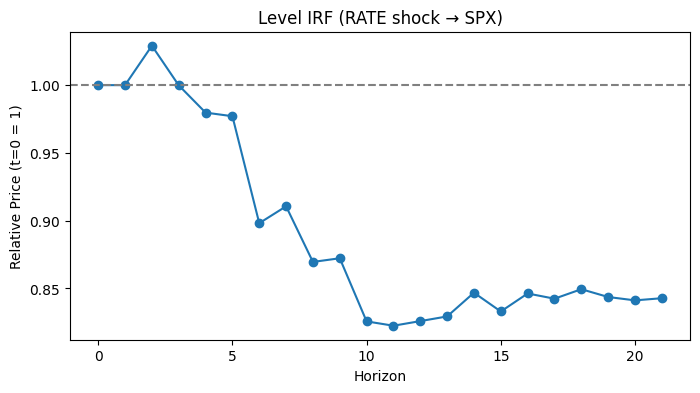

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.plot(steps, price_path, marker='o')
plt.axhline(1.0, linestyle='--', color='gray')

plt.title("Level IRF (RATE shock → SPX)")
plt.ylabel("Relative Price (t=0 = 1)")
plt.xlabel("Horizon")

plt.show()